In [13]:
import warnings
import sys

from pathlib import Path
from tqdm.auto import tqdm

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


PROJECT_ROOT = Path("/home/frantsuaza/Documents/Science/SportLab/collusion_judges")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from collusion_judges.config import LONG_DF_PATH, NODES_2_PATH, EDGES_2_PATH, GRAPH_2_PATH, NODES_3_PATH
from collusion_judges.modeling.iforest import (
    COLS_CORR_BASED,
    PARAMS_FOR_FOREST,
    get_anomaly_scores,
    get_columns,
)

%load_ext autoreload
%autoreload 2

warnings.filterwarnings("ignore")

%config InlineBackend.figure_format = "retina"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["savefig.format"] = "pdf"

sns.set_style("darkgrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **I. Import dataset and pick relevant columns**

In [3]:
judges_df = pd.read_parquet(NODES_2_PATH)

print(f"Nodes shape: {judges_df.shape}")
display(judges_df.head())

Nodes shape: (217, 182)


,judge_name,country,n_events,n_categories,fisher_aggregate_of_components_pearson_fisher_mean,fisher_aggregate_of_technique_pearson_fisher_mean,iqr_of_components_kendall_mean,iqr_of_components_kendall_median,iqr_of_components_kendall_rank_by_mean,iqr_of_components_kendall_rank_by_median,...,median_of_technique_spearman_mad,median_of_technique_spearman_max,median_of_technique_spearman_mean,median_of_technique_spearman_median,median_of_technique_spearman_min,median_of_technique_spearman_range,median_of_technique_spearman_rank_by_mean,median_of_technique_spearman_rank_by_median,median_of_technique_spearman_std,median_of_technique_spearman_upper_gap
0,Lorrie PARKER,USA,4,3,0.881108,0.913286,0.096611,0.052590,3.25,4.50,...,0.024143,0.968531,0.876488,0.889777,0.678571,0.220446,7.0,6.0,0.074473,0.072428
1,Susanne SJÖQUIST,SWE,2,2,0.925655,0.941271,0.116757,0.134869,0.75,0.25,...,0.033766,0.948918,0.847376,0.841450,0.741775,0.207143,8.0,7.5,0.077022,0.072095
2,Steven HSU,USA,1,1,0.915206,0.900173,0.008703,0.002497,0.50,0.50,...,0.053571,0.928571,0.822917,0.833333,0.690476,0.238095,7.5,7.0,0.080111,0.095238
3,Christian BAUMANN,DEU,1,1,0.916109,0.697870,0.046296,0.085970,3.00,2.50,...,0.088026,0.805876,0.653263,0.661814,0.479683,0.326193,6.5,6.5,0.114605,0.144061
4,Etsuko AZUMA,JPN,3,3,0.858657,0.938490,0.101929,0.099941,1.50,3.75,...,0.020455,0.964660,0.919549,0.931069,0.859091,0.113636,3.0,3.0,0.039594,0.037088


In [2]:
import collusion_judges.config as config

print("Config file:")
print(config.__file__)

print("\nProject root:")
print(config.PROJ_ROOT)

print("\nNODES_2_PATH:")
print(config.NODES_2_PATH)

Config file:
/home/frantsuaza/Documents/Science/SportLab/collusion_judges/collusion_judges/config.py

Project root:
/home/frantsuaza/Documents/Science/SportLab/collusion_judges

NODES_2_PATH:
/home/frantsuaza/Documents/Science/SportLab/collusion_judges/data/interim/graph/nodes_2.parquet


In [4]:
cols = list(judges_df.columns)
print(*sorted(cols), sep = '\n')

country
fisher_aggregate_of_components_pearson_fisher_mean
fisher_aggregate_of_technique_pearson_fisher_mean
iqr_of_components_kendall_mean
iqr_of_components_kendall_median
iqr_of_components_kendall_rank_by_mean
iqr_of_components_kendall_rank_by_median
iqr_of_components_pearson_mean
iqr_of_components_pearson_median
iqr_of_components_pearson_rank_by_fisher_mean
iqr_of_components_pearson_rank_by_mean
iqr_of_components_pearson_rank_by_median
iqr_of_components_spearman_mean
iqr_of_components_spearman_median
iqr_of_components_spearman_rank_by_mean
iqr_of_components_spearman_rank_by_median
iqr_of_technique_kendall_mean
iqr_of_technique_kendall_median
iqr_of_technique_kendall_rank_by_mean
iqr_of_technique_kendall_rank_by_median
iqr_of_technique_pearson_mean
iqr_of_technique_pearson_median
iqr_of_technique_pearson_rank_by_fisher_mean
iqr_of_technique_pearson_rank_by_mean
iqr_of_technique_pearson_rank_by_median
iqr_of_technique_spearman_mean
iqr_of_technique_spearman_median
iqr_of_technique_spe

# **II. Detect anomalies**

In [14]:
anomaly_df = get_anomaly_scores(
    params=PARAMS_FOR_FOREST,
    df=judges_df,
    contamination="auto",
    random_state=42,
    n_estimators=500,
    output_path=NODES_3_PATH,
)

display(anomaly_df.head())

,judge_name,country,n_categories,n_events,anomaly_score_pearson_comp_tech,anomaly_rank_pearson_comp_tech,anomaly_score_spearman_comp_tech,anomaly_rank_spearman_comp_tech,anomaly_score_kendall_comp_tech,anomaly_rank_kendall_comp_tech
0,Lorrie PARKER,USA,3,4,0.399171,150,0.394967,168,0.391791,177
1,Susanne SJÖQUIST,SWE,2,2,0.421232,96,0.477946,42,0.481307,39
2,Steven HSU,USA,1,1,0.520993,16,0.608756,4,0.563150,8
3,Christian BAUMANN,DEU,1,1,0.553387,9,0.533236,16,0.540395,15
4,Etsuko AZUMA,JPN,3,3,0.423134,90,0.417790,111,0.412681,134


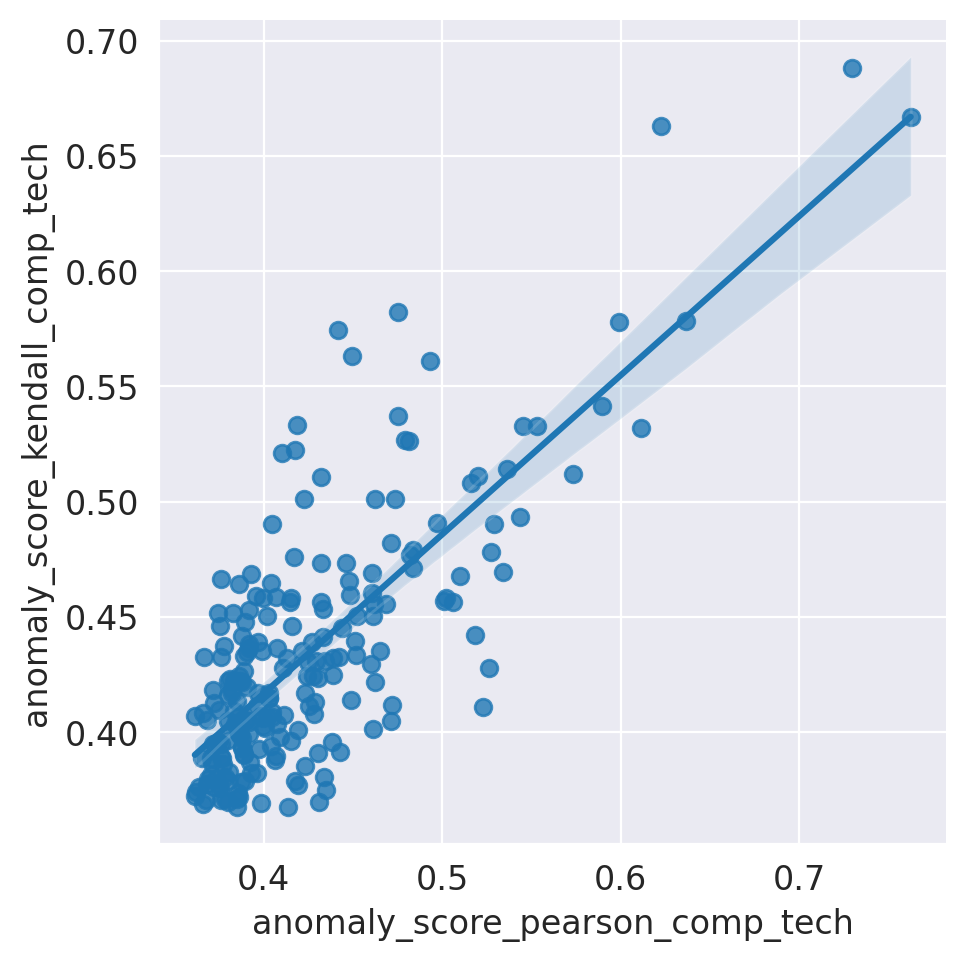

In [7]:
sns.lmplot(data=anomaly_df, x = 'anomaly_score_pearson_comp_tech', y='anomaly_score_kendall_comp_tech')

<Axes: xlabel='anomaly_score_pearson_comp_tech', ylabel='Count'>

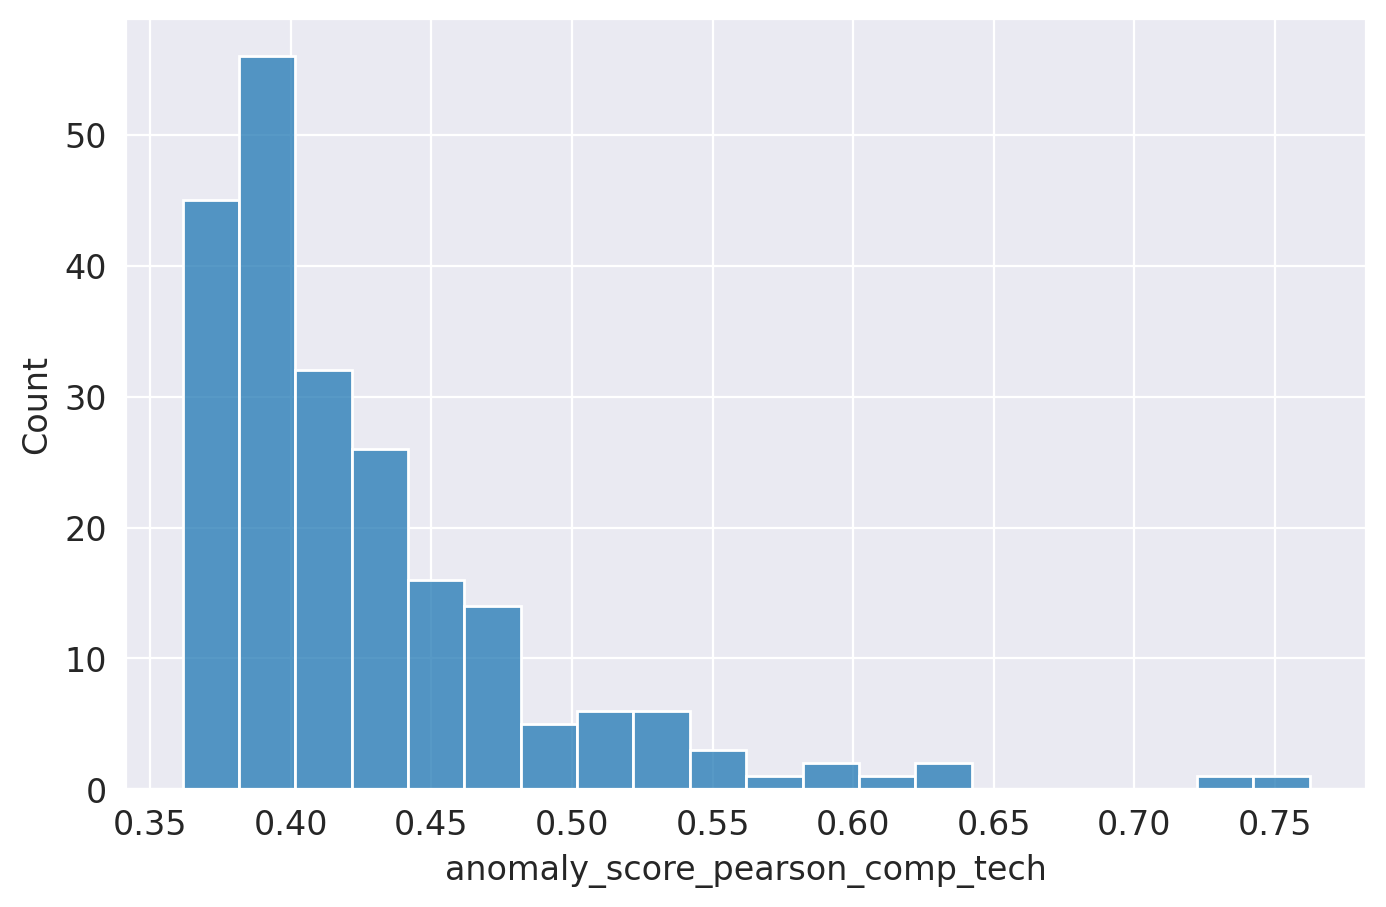

In [9]:
sns.histplot(data=anomaly_df, x='anomaly_score_pearson_comp_tech')

<Axes: xlabel='anomaly_score_kendall_comp_tech', ylabel='Count'>

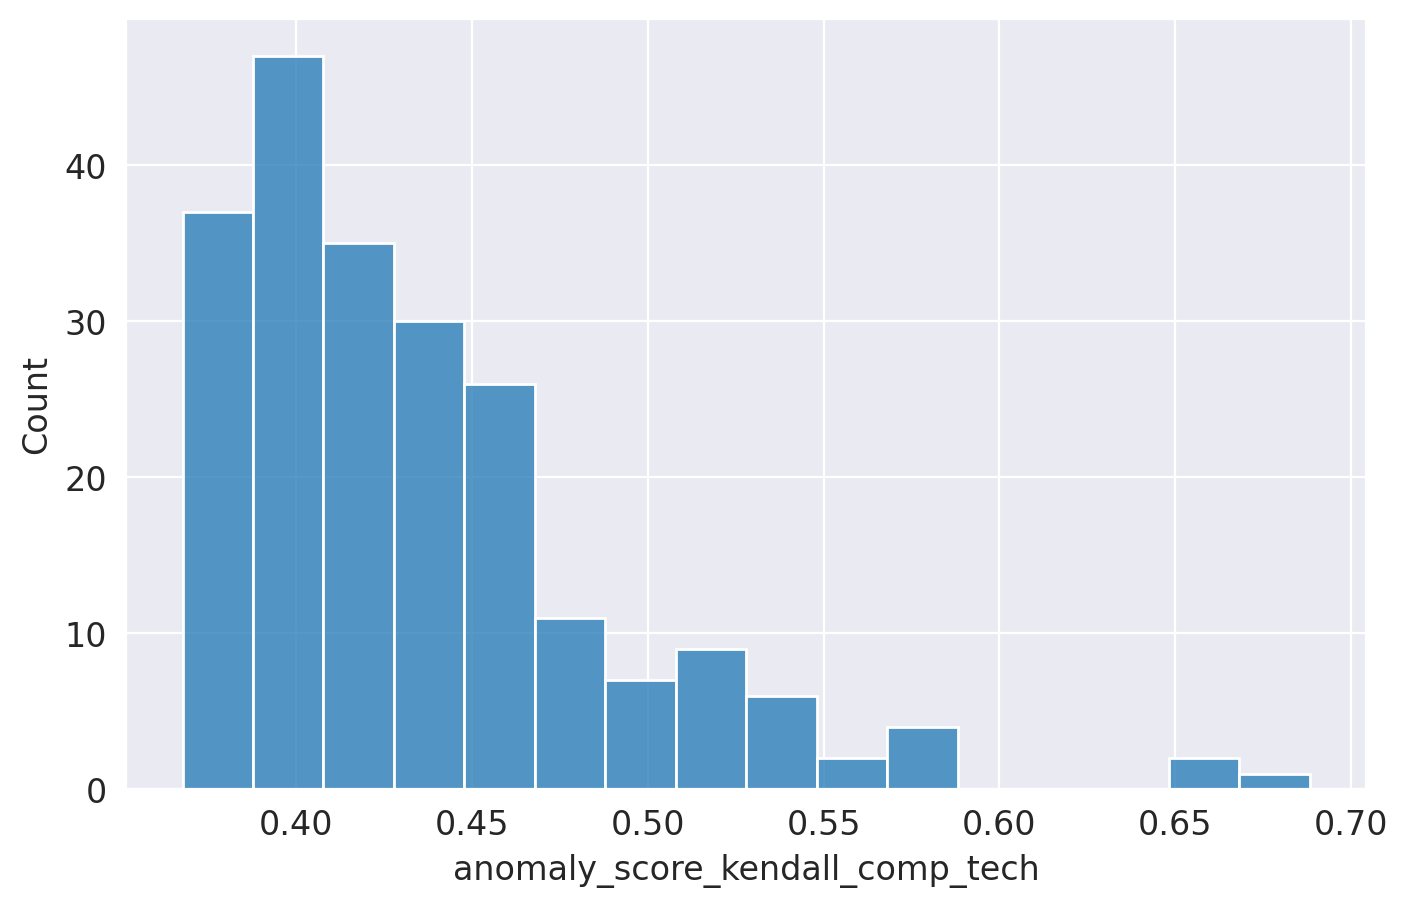

In [10]:
sns.histplot(data=anomaly_df, x='anomaly_score_kendall_comp_tech')

<Axes: xlabel='anomaly_score_kendall_comp_tech', ylabel='Count'>

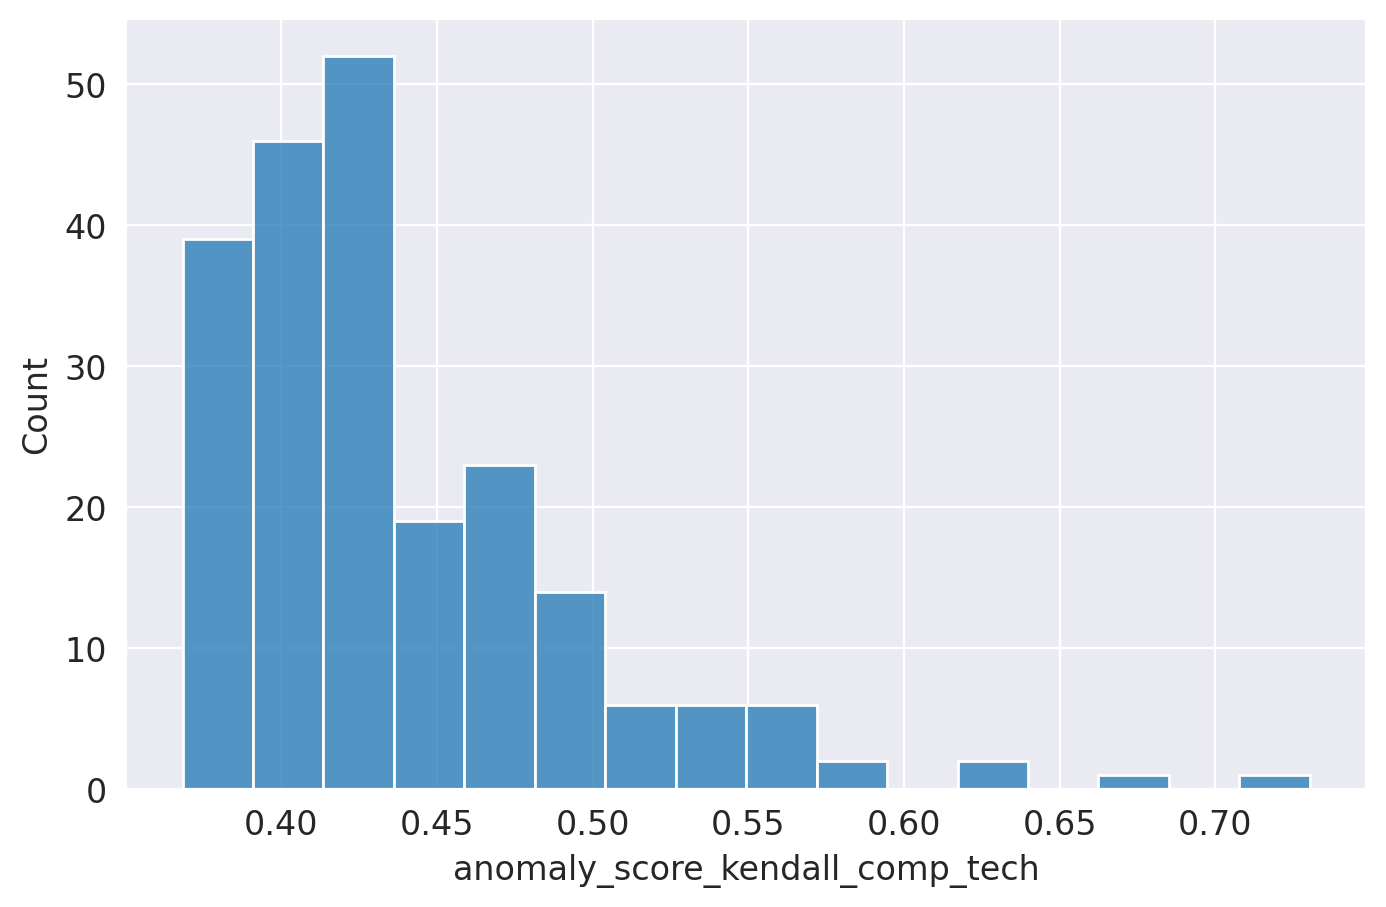

In [16]:
# without mad
sns.histplot(data=anomaly_df, x='anomaly_score_kendall_comp_tech')

<Axes: xlabel='anomaly_score_spearman_comp_tech', ylabel='Count'>

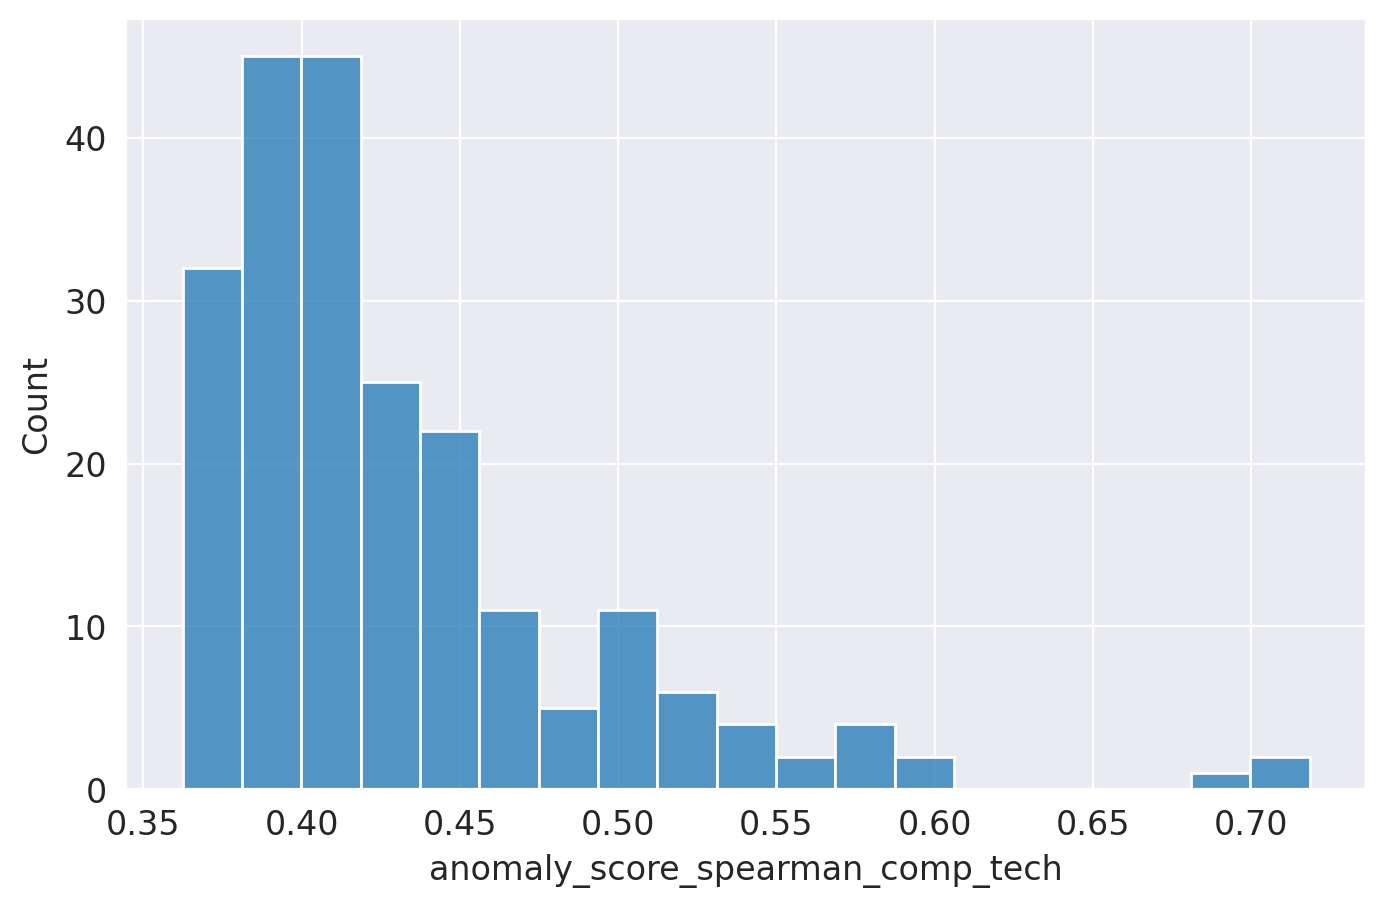

In [11]:
sns.histplot(data=anomaly_df, x='anomaly_score_spearman_comp_tech')

In [12]:
(
    anomaly_df
    .sort_values(
        "anomaly_rank_pearson_comp_tech"
    )
    .loc[
        :,
        [
            "judge_name",
            "country",
            "n_events",
            "n_categories",
            "anomaly_score_pearson_comp_tech",
            "anomaly_rank_pearson_comp_tech",
        ],
    ]
    .head(15)
)

,judge_name,country,n_events,n_categories,anomaly_score_pearson_comp_tech,anomaly_rank_pearson_comp_tech
86,Hal MARRON,USA,1,1,0.762478,1
185,Lucy LEONARD,GBR,1,1,0.729382,2
48,Christine HURTH,FRA,2,1,0.636464,3
177,Lynne DEY,CAN,1,1,0.622622,4
3,Christian BAUMANN,DEU,1,1,0.611483,5
26,Virpi KUNNAS-HELMINEN,FIN,5,1,0.599130,6
64,Hedviga FIALKOVA,SVK,2,2,0.589536,7
194,Richard GRAINGE,GBR,1,1,0.573585,8
215,Nicholas RUSSELL,GBR,1,1,0.553025,9
55,Makoto KANO,JPN,2,2,0.545074,10


In [15]:
#without mad
(
    anomaly_df
    .sort_values(
        "anomaly_rank_pearson_comp_tech"
    )
    .loc[
        :,
        [
            "judge_name",
            "country",
            "n_events",
            "n_categories",
            "anomaly_score_pearson_comp_tech",
            "anomaly_rank_pearson_comp_tech",
        ],
    ]
    .head(15)
)

,judge_name,country,n_events,n_categories,anomaly_score_pearson_comp_tech,anomaly_rank_pearson_comp_tech
185,Lucy LEONARD,GBR,1,1,0.754530,1
86,Hal MARRON,USA,1,1,0.716480,2
177,Lynne DEY,CAN,1,1,0.614240,3
64,Hedviga FIALKOVA,SVK,2,2,0.598215,4
48,Christine HURTH,FRA,2,1,0.597135,5
172,Valeria ROSA,ITA,1,1,0.564699,6
206,Szilard TOTH,HUN,1,1,0.563632,7
26,Virpi KUNNAS-HELMINEN,FIN,5,1,0.562686,8
3,Christian BAUMANN,DEU,1,1,0.553387,9
215,Nicholas RUSSELL,GBR,1,1,0.551661,10


# **III. Results analysis**